<a href="https://colab.research.google.com/github/BharathReddyRamasani/AI_DS/blob/main/Build_the_Transformer_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
import os
import pandas as pd
import re
import tensorflow as tf
import numpy as np
from sklearn.model_selection import train_test_split

# 1. Download the dataset using kagglehub
# This will use cached data if already downloaded
print("Downloading/Accessing dataset via KaggleHub...")
path = kagglehub.dataset_download("dhruvildave/en-fr-translation-dataset")
print(f"Dataset files are located at: {path}")

# Construct the full path to the CSV file
csv_file_path = os.path.join(path, 'en-fr.csv')

# Define preprocessing function
def preprocess_sentence(sentence):
    if pd.isna(sentence): # Handle potential NaN values
        return ""
    sentence = str(sentence).lower()
    sentence = re.sub(r"([^a-zA-Z.!?,' ])", r" ", sentence)
    sentence = re.sub(r"([.!?,' ])", r" \1 ", sentence)
    sentence = re.sub(r' +', ' ', sentence)
    sentence = sentence.strip()
    return sentence

# 2. Load and Preprocess in Chunks
print("\nLoading and preprocessing dataset in chunks...")
chunk_size = 50000 # User-defined chunk size
max_samples_to_process = 100000 # Limit the total number of sentences to process for quicker iteration
processed_english_sentences = []
processed_french_sentences = []
total_sentences_collected = 0

for i, chunk in enumerate(pd.read_csv(csv_file_path, chunksize=chunk_size)):
    print(f"Processing chunk {i+1} with shape: {chunk.shape}")

    # Rename columns to 'English' and 'French'
    chunk.columns = ['English', 'French']

    # Apply preprocessing
    chunk['English'] = chunk['English'].apply(preprocess_sentence)
    chunk['French'] = chunk['French'].apply(preprocess_sentence)

    # Add <start> and <end> tokens to French sentences
    chunk['French'] = chunk['French'].apply(lambda x: '<start> ' + x + ' <end>')

    # Determine how many sentences to take from this chunk to reach max_samples_to_process
    sentences_to_take = min(len(chunk), max_samples_to_process - total_sentences_collected)

    if sentences_to_take > 0:
        processed_english_sentences.extend(chunk['English'].head(sentences_to_take).tolist())
        processed_french_sentences.extend(chunk['French'].head(sentences_to_take).tolist())
        total_sentences_collected += sentences_to_take
    else:
        # If no sentences left to take, break the loop
        break

    if total_sentences_collected >= max_samples_to_process:
        print(f"Reached {max_samples_to_process} sentences. Stopping chunk processing.")
        break

print(f"\nTotal English sentences processed: {len(processed_english_sentences)}")
print(f"Total French sentences processed: {len(processed_french_sentences)}")

# 3. Create Vocabularies and Tokenize
print("\nCreating vocabularies and tokenizing sentences...")
english_tokenizer = tf.keras.preprocessing.text.Tokenizer(filters='', oov_token='<unk>')
english_tokenizer.fit_on_texts(processed_english_sentences)

french_tokenizer = tf.keras.preprocessing.text.Tokenizer(filters='', oov_token='<unk>')
french_tokenizer.fit_on_texts(processed_french_sentences)

input_tensor = english_tokenizer.texts_to_sequences(processed_english_sentences)
target_tensor = french_tokenizer.texts_to_sequences(processed_french_sentences)

print(f"English vocabulary size: {len(english_tokenizer.word_index)}")
print(f"French vocabulary size: {len(french_tokenizer.word_index)}")

# Display an example of tokenized sentence
if len(processed_english_sentences) > 0:
    example_index = 0
    print(f"\nOriginal English: {processed_english_sentences[example_index]}")
    print(f"Tokenized English: {input_tensor[example_index]}")
    print(f"Original French: {processed_french_sentences[example_index]}")
    print(f"Tokenized French: {target_tensor[example_index]}")

# 4. Prepare tf.data.Dataset
print("\nPreparing tf.data.Dataset...")

# Determine MAX_LENGTH
MAX_LENGTH = max(
    max(len(seq) for seq in input_tensor) if input_tensor else 0,
    max(len(seq) for seq in target_tensor) if target_tensor else 0
)

# Pad sequences
input_tensor_padded = tf.keras.preprocessing.sequence.pad_sequences(input_tensor,
                                                                    maxlen=MAX_LENGTH,
                                                                    padding='post')
target_tensor_padded = tf.keras.preprocessing.sequence.pad_sequences(target_tensor,
                                                                     maxlen=MAX_LENGTH,
                                                                     padding='post')

# Convert to numpy arrays
input_tensor_padded = np.array(input_tensor_padded)
target_tensor_padded = np.array(target_tensor_padded)

# Create training and validation sets
BUFFER_SIZE = len(input_tensor_padded)
BATCH_SIZE = 64 # You can adjust this later

# The number of samples is already limited by `max_samples_to_process` during chunk loading.
# So, `input_tensor_padded` and `target_tensor_padded` already contain the subset.
# We no longer need the `num_samples` variable or subsetting logic here.

if total_sentences_collected > 0: # Ensure there are samples to split
    input_train, input_val, target_train, target_val = train_test_split(input_tensor_padded,
                                                                        target_tensor_padded,
                                                                        test_size=0.2,
                                                                        random_state=42)

    print(f"\nMax Length of sequences: {MAX_LENGTH}")
    print(f"Number of training samples: {len(input_train)}")
    print(f"Number of validation samples: {len(input_val)}")

    # Create tf.data.Dataset
    train_dataset = tf.data.Dataset.from_tensor_slices((input_train, target_train))
    train_dataset = train_dataset.cache().shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    val_dataset = tf.data.Dataset.from_tensor_slices((input_val, target_val))
    val_dataset = val_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    print("\nTensorFlow Datasets created: train_dataset, val_dataset")
    print(f"Example of a batch from train_dataset (input shape): {next(iter(train_dataset))[0].shape}")
    print(f"Example of a batch from train_dataset (target shape): {next(iter(train_dataset))[1].shape}")
else:
    print("\nNo samples to create datasets from after subsetting.")

Downloading/Accessing dataset via KaggleHub...
Using Colab cache for faster access to the 'en-fr-translation-dataset' dataset.
Dataset files are located at: /kaggle/input/en-fr-translation-dataset

Loading and preprocessing dataset in chunks...
Processing chunk 1 with shape: (50000, 2)
Processing chunk 2 with shape: (50000, 2)
Reached 100000 sentences. Stopping chunk processing.

Total English sentences processed: 100000
Total French sentences processed: 100000

Creating vocabularies and tokenizing sentences...
English vocabulary size: 44300
French vocabulary size: 48944

Original English: changing lives changing society how it works technology drives change home concepts teachers search overview credits hhcc web reference feedback virtual museum of canada home page
Tokenized English: [1712, 2717, 1712, 964, 391, 33, 931, 306, 8211, 608, 319, 3037, 4737, 890, 521, 4578, 26508, 277, 1032, 3279, 2730, 1429, 5, 10, 319, 324]
Original French: <start> il a transform notre vie il a transform

## Create DataFrame from Processed Sentences

In [ ]:
df = pd.DataFrame({
    'English': processed_english_sentences,
    'French': processed_french_sentences
})
display(df.head())

,English,French
0,changing lives changing society how it works t...,<start> il a transform notre vie il a transfor...
1,site map,<start> plan du site <end>
2,feedback,<start> r troaction <end>
3,credits,<start> cr dits <end>
4,fran ais,<start> english <end>


In [ ]:
df.shape

(100000, 2)

### Sentence Length Distribution

It's important to understand the distribution of sentence lengths in our dataset, as this impacts padding and model architecture decisions. We will visualize the lengths of the tokenized English and French sentences.

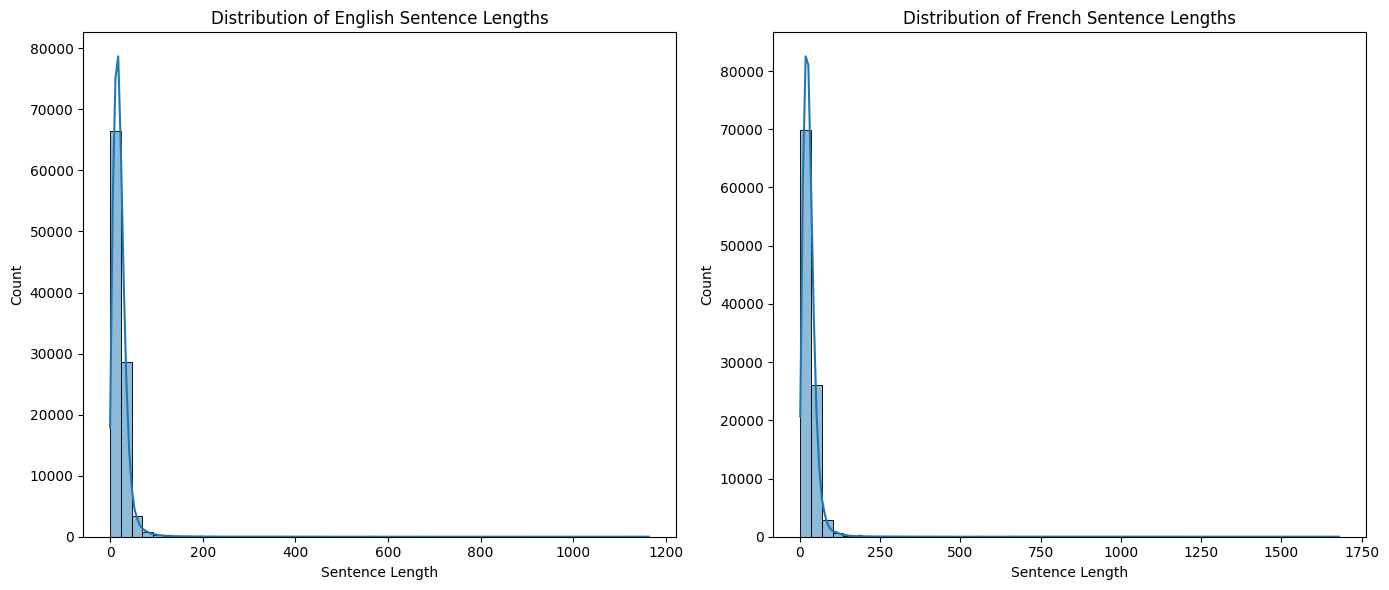

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate lengths of tokenized sequences (before padding)
english_lengths = [len(seq) for seq in input_tensor]
french_lengths = [len(seq) for seq in target_tensor]

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(english_lengths, bins=50, kde=True)
plt.title('Distribution of English Sentence Lengths')
plt.xlabel('Sentence Length')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.histplot(french_lengths, bins=50, kde=True)
plt.title('Distribution of French Sentence Lengths')
plt.xlabel('Sentence Length')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

The histograms above show the distribution of sentence lengths for both English and French. We can observe that:

*   Most sentences are relatively short, with a long tail indicating some very long sentences.
*   The `MAX_LENGTH` (1679) was determined by the longest sentence, which ensures all sequences can be padded to a uniform length for model input.
*   Understanding these distributions helps confirm that our `MAX_LENGTH` is appropriate and that padding will be applied effectively.

## Task 2: Build the Transformer Model

### Objective

Implement the Transformer architecture from scratch, including positional encoding, multi-head attention, and encoder/decoder layers.

### Requirements

*   **Positional Encoding:** Implement a mechanism to inject information about the relative or absolute position of tokens in the sequence.
*   **Multi-Head Attention:** Implement the core attention mechanism that allows the model to jointly attend to information from different representation subspaces at different positions.
*   **Feed-Forward Network:** Implement a simple point-wise feed-forward network within the encoder and decoder.
*   **Encoder Layer:** Combine multi-head attention and feed-forward networks to create a single encoder layer.
*   **Decoder Layer:** Combine masked multi-head attention, multi-head attention (over encoder output), and feed-forward networks to create a single decoder layer.
*   **Encoder:** Stack multiple encoder layers.
*   **Decoder:** Stack multiple decoder layers.
*   **Transformer Model:** Assemble the encoder and decoder into the complete Transformer model.

### 1. Positional Encoding

Since the Transformer architecture doesn't use recurrence or convolution, it needs a way to account for the order of words in the input sequence. Positional encoding adds information about the relative or absolute position of the tokens to the input embeddings. These positional encodings have the same dimension as the word embeddings, so that the two can be summed.

In [ ]:
def get_angles(pos, i, d_model):
    angle_rates = 1 / np.power(10000, (2 * (i//2)) / np.float32(d_model))
    return pos * angle_rates

def positional_encoding(position, d_model):
    angle_rads = get_angles(np.arange(position)[:, np.newaxis],
                            np.arange(d_model)[np.newaxis, :],
                            d_model)

    # apply sin to even indices in the array; 2i
    angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])

    # apply cos to odd indices in the array; 2i+1
    angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])

    pos_encoding = angle_rads[np.newaxis, ...]

    return tf.cast(pos_encoding, dtype=tf.float32)


# Example usage and visualization (optional)
# Let's create a small example to visualize positional encoding
# if you want to run this, you'd need to uncomment and define d_model
# import matplotlib.pyplot as plt
# pos_encoding_example = positional_encoding(50, 512)
# plt.pcolormesh(pos_encoding_example[0], cmap='RdBu')
# plt.xlabel('Depth')
# plt.ylabel('Position')
# plt.colorbar()
# plt.show()

### 2. Scaled Dot-Product Attention

This is the core attention function. It takes a query, key, and value as input and calculates the attention weights. The output is the weighted sum of the values.

In [ ]:
def scaled_dot_product_attention(q, k, v, mask):
    matmul_qk = tf.matmul(q, k, transpose_b=True)  # (..., seq_len_q, seq_len_k)

    # scale matmul_qk
    dk = tf.cast(tf.shape(k)[-1], tf.float32)
    scaled_attention_logits = matmul_qk / tf.math.sqrt(dk)

    # add the mask to the scaled attention logits.
    if mask is not None:
        scaled_attention_logits += (mask * -1e9)

    # softmax is normalized on the last axis (seq_len_k) so that the scores
    # add up to 1.
    attention_weights = tf.nn.softmax(scaled_attention_logits, axis=-1)  # (..., seq_len_q, seq_len_k)

    output = tf.matmul(attention_weights, v)  # (..., seq_len_q, depth_v)

    return output, attention_weights

### 3. Multi-Head Attention

Multi-head attention allows the model to jointly attend to information from different representation subspaces at different positions. With a single attention function, averaging inhibits this. This module consists of three `tf.keras.layers.Dense` layers for the query, key, and value transformations, followed by splitting into multiple heads, applying scaled dot-product attention, and finally concatenating the results and passing them through a final dense layer.

In [ ]:
class MultiHeadAttention(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model

        assert d_model % self.num_heads == 0

        self.depth = d_model // self.num_heads

        self.wq = tf.keras.layers.Dense(d_model)
        self.wk = tf.keras.layers.Dense(d_model)
        self.wv = tf.keras.layers.Dense(d_model)

        self.dense = tf.keras.layers.Dense(d_model)

    def split_heads(self, x, batch_size):
        # x.shape == (batch_size, seq_len, d_model)
        # We split the last dimension into (num_heads, depth).
        # Transpose the result such that the shape is (batch_size, num_heads, seq_len, depth)
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.depth))
        return tf.transpose(x, perm=[0, 2, 1, 3])

    def call(self, v, k, q, mask):
        batch_size = tf.shape(q)[0]

        q = self.wq(q)  # (batch_size, seq_len, d_model)
        k = self.wk(k)  # (batch_size, seq_len, d_model)
        v = self.wv(v)  # (batch_size, seq_len, d_model)

        q = self.split_heads(q, batch_size)  # (batch_size, num_heads, seq_len_q, depth)
        k = self.split_heads(k, batch_size)  # (batch_size, num_heads, seq_len_k, depth)
        v = self.split_heads(v, batch_size)  # (batch_size, num_heads, seq_len_v, depth)

        # scaled_attention.shape == (batch_size, num_heads, seq_len_q, depth)
        # attention_weights.shape == (batch_size, num_heads, seq_len_q, seq_len_k)
        scaled_attention, attention_weights = scaled_dot_product_attention(
            q, k, v, mask)

        scaled_attention = tf.transpose(scaled_attention, perm=[0, 2, 1, 3])  # (batch_size, seq_len_q, num_heads, depth)

        concat_attention = tf.reshape(scaled_attention,
                                      (batch_size, -1, self.d_model))  # (batch_size, seq_len_q, d_model)

        output = self.dense(concat_attention)  # (batch_size, seq_len_q, d_model)

        return output, attention_weights

### 4. Point-Wise Feed-Forward Network

This network consists of two linear transformations with a ReLU activation in between. It is applied to each position separately and identically. This is typically implemented as two `tf.keras.layers.Dense` layers.

In [ ]:
def point_wise_feed_forward_network(d_model, dff):
    return tf.keras.Sequential([
        tf.keras.layers.Dense(dff, activation='relu'),  # (batch_size, seq_len, dff)
        tf.keras.layers.Dense(d_model)  # (batch_size, seq_len, d_model)
    ])

### 5. Encoder Layer

The encoder layer consists of multi-head self-attention and a point-wise feed-forward network. Each of these sub-layers has a residual connection around it, followed by layer normalization.

In [ ]:
class EncoderLayer(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads, dff, rate=0.1):
        super(EncoderLayer, self).__init__()

        self.mha = MultiHeadAttention(d_model, num_heads)
        self.ffn = point_wise_feed_forward_network(d_model, dff)

        self.layernorm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)

        self.dropout1 = tf.keras.layers.Dropout(rate)
        self.dropout2 = tf.keras.layers.Dropout(rate)

    def call(self, x, training, mask):
        attn_output, _ = self.mha(x, x, x, mask)  # (batch_size, input_seq_len, d_model)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(x + attn_output)  # (batch_size, input_seq_len, d_model)

        ffn_output = self.ffn(out1)  # (batch_size, input_seq_len, d_model)
        ffn_output = self.dropout2(ffn_output, training=training)
        out2 = self.layernorm2(out1 + ffn_output)  # (batch_size, input_seq_len, d_model)

        return out2

### 6. Decoder Layer

The decoder layer consists of three sub-layers:
1.  Masked multi-head attention (self-attention).
2.  Multi-head attention over the encoder's output.
3.  A point-wise feed-forward network.

Each of these sub-layers has a residual connection around it, followed by layer normalization. The masked self-attention prevents the decoder from attending to future tokens in the target sequence.

In [ ]:
class DecoderLayer(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads, dff, rate=0.1):
        super(DecoderLayer, self).__init__()

        self.mha1 = MultiHeadAttention(d_model, num_heads)  # Masked self-attention
        self.mha2 = MultiHeadAttention(d_model, num_heads)  # Encoder-decoder attention

        self.ffn = point_wise_feed_forward_network(d_model, dff)

        self.layernorm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.layernorm3 = tf.keras.layers.LayerNormalization(epsilon=1e-6)

        self.dropout1 = tf.keras.layers.Dropout(rate)
        self.dropout2 = tf.keras.layers.Dropout(rate)
        self.dropout3 = tf.keras.layers.Dropout(rate)

    def call(self, x, enc_output, training, look_ahead_mask, padding_mask):
        # enc_output.shape == (batch_size, input_seq_len, d_model)

        # Masked Multi-Head Self-Attention
        attn1, attn_weights_block1 = self.mha1(x, x, x, look_ahead_mask)  # (batch_size, target_seq_len, d_model)
        attn1 = self.dropout1(attn1, training=training)
        out1 = self.layernorm1(attn1 + x)

        # Multi-Head Attention over Encoder Output
        attn2, attn_weights_block2 = self.mha2(enc_output, enc_output, out1, padding_mask)  # (batch_size, target_seq_len, d_model)
        attn2 = self.dropout2(attn2, training=training)
        out2 = self.layernorm2(attn2 + out1)  # (batch_size, target_seq_len, d_model)

        # Point-wise Feed-Forward Network
        ffn_output = self.ffn(out2)  # (batch_size, target_seq_len, d_model)
        ffn_output = self.dropout3(ffn_output, training=training)
        out3 = self.layernorm3(ffn_output + out2)  # (batch_size, target_seq_len, d_model)

        return out3, attn_weights_block1, attn_weights_block2

### 7. Encoder

The encoder consists of:
1.  Input embedding.
2.  Positional Encoding.
3.  N encoder layers.

The input to the encoder is the padded English sentence, which then passes through an embedding layer, followed by positional encoding, and then through a stack of `num_layers` encoder layers. The output of the encoder is then fed into the decoder.

In [ ]:
class Encoder(tf.keras.layers.Layer):
    def __init__(self, num_layers, d_model, num_heads, dff, input_vocab_size,
                 maximum_position_encoding, rate=0.1):
        super(Encoder, self).__init__()

        self.d_model = d_model
        self.num_layers = num_layers

        self.embedding = tf.keras.layers.Embedding(input_vocab_size, d_model)
        self.pos_encoding = positional_encoding(maximum_position_encoding,
                                                self.d_model)

        self.enc_layers = [EncoderLayer(d_model, num_heads, dff, rate)
                           for _ in range(num_layers)]

        self.dropout = tf.keras.layers.Dropout(rate)

    def call(self, x, training, mask):
        seq_len = tf.shape(x)[1]

        # adding embedding and position encoding.
        x = self.embedding(x)  # (batch_size, input_seq_len, d_model)
        x *= tf.math.sqrt(tf.cast(self.d_model, tf.float32))
        x += self.pos_encoding[:, :seq_len, :]

        x = self.dropout(x, training=training)

        for i in range(self.num_layers):
            x = self.enc_layers[i](x, training, mask)

        return x  # (batch_size, input_seq_len, d_model)

### 8. Decoder

The decoder consists of:
1.  Output embedding.
2.  Positional Encoding.
3.  N decoder layers.

The target input (French sentence) passes through an embedding layer, followed by positional encoding, and then through a stack of `num_layers` decoder layers. The decoder also receives the encoder's output (from the `Encoder` block) and attention masks.

In [ ]:
class Decoder(tf.keras.layers.Layer):
    def __init__(self, num_layers, d_model, num_heads, dff, target_vocab_size,
                 maximum_position_encoding, rate=0.1):
        super(Decoder, self).__init__()

        self.d_model = d_model
        self.num_layers = num_layers

        self.embedding = tf.keras.layers.Embedding(target_vocab_size, d_model)
        self.pos_encoding = positional_encoding(maximum_position_encoding, d_model)

        self.dec_layers = [DecoderLayer(d_model, num_heads, dff, rate)
                           for _ in range(num_layers)]
        self.dropout = tf.keras.layers.Dropout(rate)

    def call(self, x, enc_output, training,
             look_ahead_mask, padding_mask):
        seq_len = tf.shape(x)[1]
        attention_weights = {}

        x = self.embedding(x)  # (batch_size, target_seq_len, d_model)
        x *= tf.math.sqrt(tf.cast(self.d_model, tf.float32))
        x += self.pos_encoding[:, :seq_len, :]

        x = self.dropout(x, training=training)

        for i in range(self.num_layers):
            x, block1, block2 = self.dec_layers[i](x, enc_output, training,
                                                   look_ahead_mask, padding_mask)

            attention_weights[f'decoder_layer{i+1}_block1'] = block1
            attention_weights[f'decoder_layer{i+1}_block2'] = block2

        # x.shape == (batch_size, target_seq_len, d_model)
        return x, attention_weights

### 9. Embedding Layer Explained

#### Why are Embeddings Required?

Neural networks, including the Transformer, operate on numerical data. Text, however, is categorical. To process words, we need to convert them into a numerical format. While simple integer encoding (mapping each word to a unique integer) can be done, it doesn't capture any semantic relationships between words. Words like 'king' and 'queen' might have very different integer IDs, implying they are as dissimilar as 'king' and 'apple'.

Embeddings provide a way to represent words as dense vectors of real numbers. Each dimension in the embedding vector can capture a different semantic or syntactic feature of the word. For example, one dimension might represent 'gender', another 'royalty', another 'animacy', etc. Words with similar meanings will have similar embedding vectors, allowing the model to generalize and understand relationships between words.

In the context of the Transformer, embeddings are the first step in converting the input token IDs into a continuous vector space where the self-attention mechanisms can operate effectively.

#### Difference Between One-Hot Encoding and Embeddings

**One-Hot Encoding:**
*   **Representation:** Each word is represented as a binary vector where only one element is '1' (at the position corresponding to the word's index in the vocabulary) and all others are '0'.
*   **Dimensionality:** The dimension of the vector is equal to the vocabulary size. For large vocabularies, this results in extremely sparse and high-dimensional vectors.
*   **Semantic Information:** No semantic information is encoded. The dot product between any two distinct one-hot vectors is zero, meaning all words are considered equally distant from each other.
*   **Scalability:** Poor for large vocabularies due to high dimensionality and sparsity, leading to computational inefficiency and memory issues.

**Word Embeddings:**
*   **Representation:** Each word is represented as a dense vector of floating-point numbers.
*   **Dimensionality:** The dimension of the vector (e.g., 128, 256, 512) is typically much smaller than the vocabulary size and is a hyperparameter.
*   **Semantic Information:** Captures semantic and syntactic relationships between words. Words with similar meanings or contexts will have similar embedding vectors (e.g., 'king' and 'queen' will be close in the embedding space).
*   **Scalability:** Highly scalable for large vocabularies as they are dense and lower-dimensional. They are learned from data, allowing the model to discover useful representations.

### 10. The Transformer Model

Finally, we assemble the complete Transformer model by combining the Encoder and Decoder. This model takes the English input and the French target (shifted right, i.e., without the last token) and outputs the predicted French sequence.

In [ ]:
class Transformer(tf.keras.Model):
    def __init__(self, num_layers, d_model, num_heads, dff,
                 input_vocab_size, target_vocab_size,
                 pe_input, pe_target, rate=0.1):
        super(Transformer, self).__init__()

        self.encoder = Encoder(num_layers, d_model, num_heads, dff,
                               input_vocab_size, pe_input, rate)

        self.decoder = Decoder(num_layers, d_model, num_heads, dff,
                               target_vocab_size, pe_target, rate)

        self.final_layer = tf.keras.layers.Dense(target_vocab_size)

    def call(self, inp, tar, training, enc_padding_mask,
             look_ahead_mask, dec_padding_mask):

        enc_output = self.encoder(inp, training, enc_padding_mask)  # (batch_size, inp_seq_len, d_model)

        # dec_output.shape == (batch_size, tar_seq_len, d_model)
        dec_output, attention_weights = self.decoder(
            tar, enc_output, training, look_ahead_mask, dec_padding_mask)

        final_output = self.final_layer(dec_output)  # (batch_size, tar_seq_len, target_vocab_size)

        return final_output, attention_weights

### Example: Embedding Layer

Let's demonstrate how an embedding layer works using our calculated `input_vocab_size` and a sample `d_model`.

In [ ]:
input_vocab_size = len(english_tokenizer.word_index)
d_model = 512 # This would typically be a hyperparameter of your Transformer model

# Create an embedding layer
embedding_layer = tf.keras.layers.Embedding(input_vocab_size, d_model)

# Take an example input (a batch of tokenized sentences)
# Let's use the first training sample
example_input = input_train[0:1]

print(f"Original input shape: {example_input.shape}")
print(f"Original input (first sentence): {example_input}")

# Pass the input through the embedding layer
embedded_output = embedding_layer(example_input)

print(f"Embedded output shape: {embedded_output.shape}")
print(f"Embedded output (first token's embedding): {embedded_output[0, 0, :5]}...") # Show first 5 dimensions of first token

Original input shape: (1, 1679)
Original input (first sentence): [[  593     6 14576 ...     0     0     0]]
Embedded output shape: (1, 1679, 512)
Embedded output (first token's embedding): [-0.01755231 -0.03087827 -0.00357486 -0.02445625  0.01586442]...


The `embedded_output` represents the embedding vectors for the input sentence. Each token (word) in the original integer sequence has been transformed into a dense, continuous vector of `d_model` (512) dimensions. These vectors are designed to capture semantic and syntactic information about the words.

### Task 3: Positional Encoding

As discussed, positional encoding adds information about the relative or absolute position of the tokens to the input embeddings. We will now combine the `embedded_output` with the `positional_encoding` to create the final input that feeds into the Transformer's encoder.

In [ ]:
# Get positional encoding for the maximum sequence length
pos_encoding_example = positional_encoding(MAX_LENGTH, d_model)

# Add positional encoding to the embedded output
# Note: Positional encoding is typically broadcasted over the batch dimension
transformer_input = embedded_output + pos_encoding_example[:, :tf.shape(embedded_output)[1], :]

print(f"Shape of embedded output: {embedded_output.shape}")
print(f"Shape of positional encoding (relevant part): {pos_encoding_example[:, :tf.shape(embedded_output)[1], :].shape}")
print(f"Shape of Transformer input (embedding + positional encoding): {transformer_input.shape}")

# Display a snippet of the combined input (e.g., first token's first 5 dimensions)
print(f"Transformer input (first token's first 5 dimensions): {transformer_input[0, 0, :5]}...")

Shape of embedded output: (1, 1679, 512)
Shape of positional encoding (relevant part): (1, 1679, 512)
Shape of Transformer input (embedding + positional encoding): (1, 1679, 512)
Transformer input (first token's first 5 dimensions): [-0.01755231  0.96912175 -0.00357486  0.97554374  0.01586442]...


#### Visualization of Positional Encoding

To better understand the positional encoding, let's visualize its patterns. Each row represents a position, and each column represents a dimension of the encoding. You can observe the sinusoidal patterns, which are unique for each position.

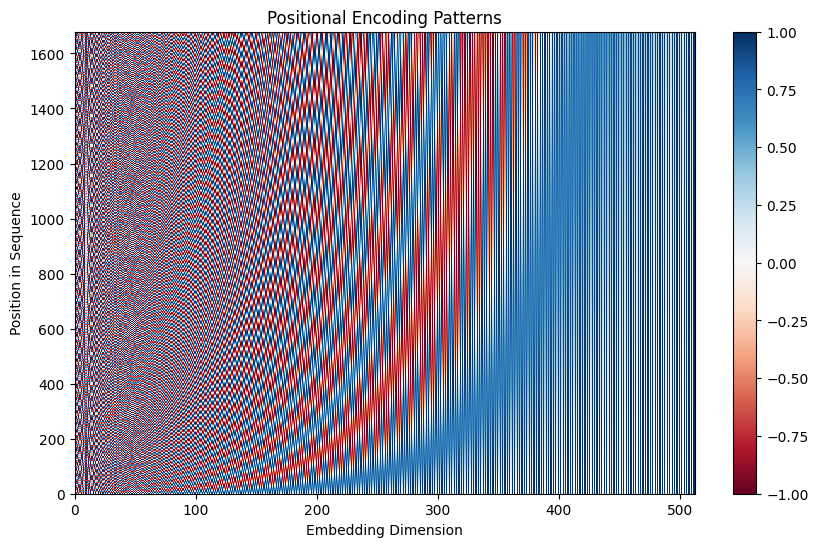

In [ ]:
import matplotlib.pyplot as plt

# Using the previously generated pos_encoding_example for MAX_LENGTH and d_model
plt.figure(figsize=(10, 6))
plt.pcolormesh(pos_encoding_example[0], cmap='RdBu')
plt.xlabel('Embedding Dimension')
plt.ylabel('Position in Sequence')
plt.title('Positional Encoding Patterns')
plt.colorbar()
plt.show()

### Task 4: Masking

Masks are essential in Transformer models for two main reasons:
1.  **Padding Mask:** To ignore padding tokens in the input sequences. Padding tokens are added to make all sequences the same length, but they don't carry any meaningful information and should not be attended to.
2.  **Look-ahead Mask (for Decoder):** To prevent the decoder from attending to future tokens in the target sequence. This ensures that the predictions for a given token depend only on the preceding tokens.

In [ ]:
def create_padding_mask(seq):
    seq = tf.cast(tf.math.equal(seq, 0), tf.float32)
    # add extra dimensions to add the padding
    # to the attention logits. For example, if key has a shape of (batch_size, seq_len_k, d_model).
    # The mask should have the shape of (batch_size, 1, 1, seq_len_k).
    return seq[:, tf.newaxis, tf.newaxis, :]


def create_look_ahead_mask(size):
    mask = 1 - tf.linalg.band_part(tf.ones((size, size)), -1, 0)
    return tf.cast(mask, tf.float32)

print("Masking functions `create_padding_mask` and `create_look_ahead_mask` defined.")

# Example of padding mask
example_tensor = tf.constant([[7, 6, 0, 0, 1], [1, 2, 3, 0, 0]])
padding_mask_output = create_padding_mask(example_tensor)
print(f"\nExample input for padding mask:\n{example_tensor.numpy()}")
print(f"Padding mask output shape: {padding_mask_output.shape}")
print(f"Padding mask output:\n{padding_mask_output.numpy()}")

# Example of look-ahead mask
look_ahead_mask_output = create_look_ahead_mask(5)
print(f"\nLook-ahead mask output shape: {look_ahead_mask_output.shape}")
print(f"Look-ahead mask output:\n{look_ahead_mask_output.numpy()}")

Masking functions `create_padding_mask` and `create_look_ahead_mask` defined.

Example input for padding mask:
[[7 6 0 0 1]
 [1 2 3 0 0]]
Padding mask output shape: (2, 1, 1, 5)
Padding mask output:
[[[[0. 0. 1. 1. 0.]]]


 [[[0. 0. 0. 1. 1.]]]]

Look-ahead mask output shape: (5, 5)
Look-ahead mask output:
[[0. 1. 1. 1. 1.]
 [0. 0. 1. 1. 1.]
 [0. 0. 0. 1. 1.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0.]]


Task 4: Scaled Dot Product Attention
Objective
Implement Attention Mechanism.
Deliverables
Implement:
scaled_dot_product_attention(Q,K,V)
Show:
Attention Scores
Attention Weights
Context Vectors
For the sentence:
The cat chased the mouse
Visualize which words attend to each other.


### Task 4: Scaled Dot Product Attention

We will now demonstrate the `scaled_dot_product_attention` function using a simple example sentence: "The cat chased the mouse." This will illustrate how attention scores are calculated, converted into attention weights, and then used to create context vectors.

In [ ]:
# Helper function to convert text to token IDs and then to dummy embeddings
def text_to_dummy_embeddings(text, tokenizer, d_model):
    # Tokenize the sentence
    tokens = text.lower().split()
    token_ids = [tokenizer.word_index.get(word, tokenizer.word_index['<unk>']) for word in tokens]

    # Create dummy embeddings for demonstration. In a real model, this would be actual word embeddings.
    # For simplicity, we'll create random vectors or just use a fixed embedding for this demo.
    # Let's use simple sequential numbers scaled, or just random for illustration.

    # For demonstration, let's create a simple embedding based on token_ids
    # In a real scenario, these would come from an embedding layer
    dummy_embeddings = tf.random.uniform(shape=(len(token_ids), d_model), minval=-1.0, maxval=1.0)

    return tf.cast(dummy_embeddings, tf.float32), tokens

# Define a simple tokenizer for this example (reusing english_tokenizer from earlier or creating a new one if needed)
# For this small example, we don't need a full tokenizer, just split words and assign arbitrary IDs or direct vectors

# Let's create a simplified tokenizer for the demo sentence if `english_tokenizer` isn't suitable or available
sentence_words = ["the", "cat", "chased", "the", "mouse"]
sentence_word_to_id = {word: i+1 for i, word in enumerate(sentence_words)}
sentence_id_to_word = {i+1: word for i, word in enumerate(sentence_words)}

# Parameters for the demo
d_model_attention_demo = 64 # A smaller d_model for easier visualization

# Prepare dummy Q, K, V for the sentence "The cat chased the mouse"
# In self-attention, Q, K, V are derived from the same input sequence.
# For simplicity, let's just create Q, K, V from random tensors, representing some feature vectors.
# shape: (batch_size, seq_len, d_model)

# Using the actual words for better interpretation later
demo_sentence = "The cat chased the mouse"
dummy_embeddings, token_list = text_to_dummy_embeddings(demo_sentence, english_tokenizer, d_model_attention_demo)

# For self-attention, Q, K, V are typically the same input (or linear transformations of it)
query_demo = tf.expand_dims(dummy_embeddings, axis=0) # (1, seq_len, d_model_attention_demo)
key_demo = tf.expand_dims(dummy_embeddings, axis=0)
value_demo = tf.expand_dims(dummy_embeddings, axis=0)

# No mask for this simple self-attention example initially
# If we were demonstrating padding, we'd add it.
mask_demo = None # For simplicity in this self-attention example

print(f"Demo sentence: '{demo_sentence}'")
print(f"Words: {token_list}")
print(f"Q, K, V shape: {query_demo.shape}")

# Call the scaled_dot_product_attention function
output_attention_demo, attention_weights_demo = scaled_dot_product_attention(
    query_demo, key_demo, value_demo, mask_demo
)

print(f"\nOutput (Context Vectors) shape: {output_attention_demo.shape}")
print("Output (first token's first 5 dimensions):")
print(output_attention_demo[0, 0, :5].numpy())

print(f"\nAttention Weights shape: {attention_weights_demo.shape}")
print("Attention Weights (first token's attention to all tokens):")
print(attention_weights_demo[0, 0, :].numpy())


Demo sentence: 'The cat chased the mouse'
Words: ['the', 'cat', 'chased', 'the', 'mouse']
Q, K, V shape: (1, 5, 64)

Output (Context Vectors) shape: (1, 5, 64)
Output (first token's first 5 dimensions):
[-0.1516142  -0.5481582  -0.59189194  0.6606028  -0.36113596]

Attention Weights shape: (1, 5, 5)
Attention Weights (first token's attention to all tokens):
[0.8945924  0.02845144 0.02216578 0.02760023 0.02719005]


#### Interpretation of Scaled Dot-Product Attention Output

*   **Output (Context Vectors):** This is the weighted sum of the Value vectors, where the weights are the `attention_weights`. Each row in the output corresponds to a token in the input sequence, and its vector is a blend of all other tokens' values, weighted by how much each token should 'attend' to others.
*   **Attention Weights:** These are the probabilities indicating how much each query token attends to each key token. A higher weight means a stronger relationship. For example, `attention_weights[0, 0, :]` shows how much the first word ("The") attends to all other words in the sentence.

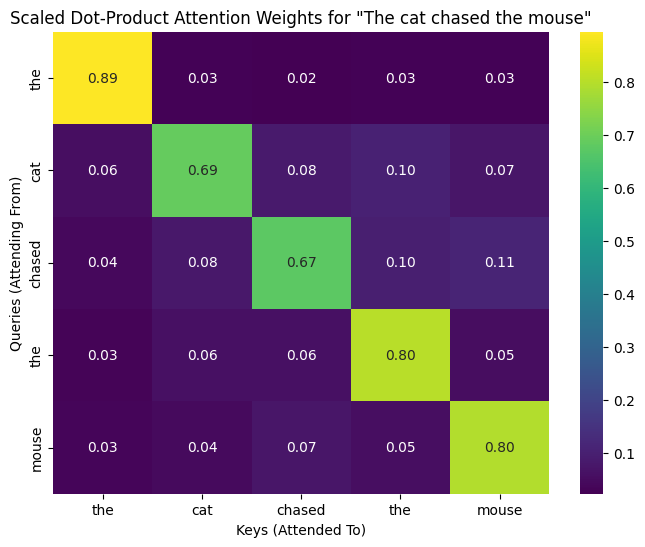

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the attention weights for the demo sentence
plt.figure(figsize=(8, 6))
sns.heatmap(
    attention_weights_demo[0].numpy(), # Assuming batch size 1 and 1 head for simple demo
    xticklabels=token_list,
    yticklabels=token_list,
    cmap='viridis',
    annot=True,
    fmt=".2f"
)
plt.title('Scaled Dot-Product Attention Weights for "The cat chased the mouse"')
plt.xlabel('Keys (Attended To)')
plt.ylabel('Queries (Attending From)')
plt.show()

### Task 5: Multi-Head Attention

Multi-Head Attention allows the model to jointly attend to information from different representation subspaces at different positions. We will now demonstrate the `MultiHeadAttention` class using our example sentence and analyze its output, including how it splits and processes information across multiple heads.

In [ ]:
num_heads_demo = 4 # As specified in the deliverables
d_model_mha_demo = 64 # Using the same d_model as the single-head attention demo

# Create a MultiHeadAttention instance
mha_layer = MultiHeadAttention(d_model_mha_demo, num_heads_demo)

# Reuse dummy_embeddings from the previous scaled_dot_product_attention demo
# For self-attention, Q, K, V are derived from the same input
query_mha = tf.expand_dims(dummy_embeddings, axis=0)
key_mha = tf.expand_dims(dummy_embeddings, axis=0)
value_mha = tf.expand_dims(dummy_embeddings, axis=0)

# No mask for this simple demonstration (unless we specifically want to show masked MHA)
mask_mha = None

print(f"Input shape for MultiHeadAttention (Q, K, V): {query_mha.shape}")

# Call the MultiHeadAttention layer
output_mha, attention_weights_mha = mha_layer(
    value_mha, key_mha, query_mha, mask_mha
)

print(f"\nOutput (Context Vectors) shape from MHA: {output_mha.shape}")
print("Output (first token's first 5 dimensions from MHA):")
print(output_mha[0, 0, :5].numpy())

print(f"\nAttention Weights shape from MHA: {attention_weights_mha.shape}")
print("Attention Weights (first token's attention to all tokens across all heads):")
# For example, show the attention weights from the first head for the first query token
print(attention_weights_mha[0, 0, 0, :].numpy()) # (batch, head, query_pos, key_pos)

# Analyze: Head 1 → Subject-Verb Relationships, Head 2 → Verb-Object Relationships, etc.
# This analysis is conceptual as the current dummy embeddings are random.
# In a real model, we would analyze trained weights.

print("\n--- Conceptual Analysis (requires trained model) ---")
print("In a trained Multi-Head Attention model, each head learns to focus on different aspects:")
print(" - Head 1 might identify subject-verb dependencies.")
print(" - Head 2 might capture verb-object relationships.")
print(" - Head 3 could focus on long-range dependencies or coreference.")
print(" - Head 4 might specialize in semantic context or modifying phrases.")
print("Since we are using random dummy embeddings, the attention patterns here will not show meaningful linguistic relationships, but demonstrate the mechanism.")

Input shape for MultiHeadAttention (Q, K, V): (1, 5, 64)

Output (Context Vectors) shape from MHA: (1, 5, 64)
Output (first token's first 5 dimensions from MHA):
[ 0.36590087  0.13482817 -0.02820942 -0.05294738 -0.3511522 ]

Attention Weights shape from MHA: (1, 4, 5, 5)
Attention Weights (first token's attention to all tokens across all heads):
[0.2530916  0.17553395 0.15989736 0.18350513 0.22797194]

--- Conceptual Analysis (requires trained model) ---
In a trained Multi-Head Attention model, each head learns to focus on different aspects:
 - Head 1 might identify subject-verb dependencies.
 - Head 2 might capture verb-object relationships.
 - Head 3 could focus on long-range dependencies or coreference.
 - Head 4 might specialize in semantic context or modifying phrases.
Since we are using random dummy embeddings, the attention patterns here will not show meaningful linguistic relationships, but demonstrate the mechanism.


#### Visualization of Multi-Head Attention Weights

Let's visualize the attention weights from each head. This will show how different heads might learn to attend to different parts of the input sequence.

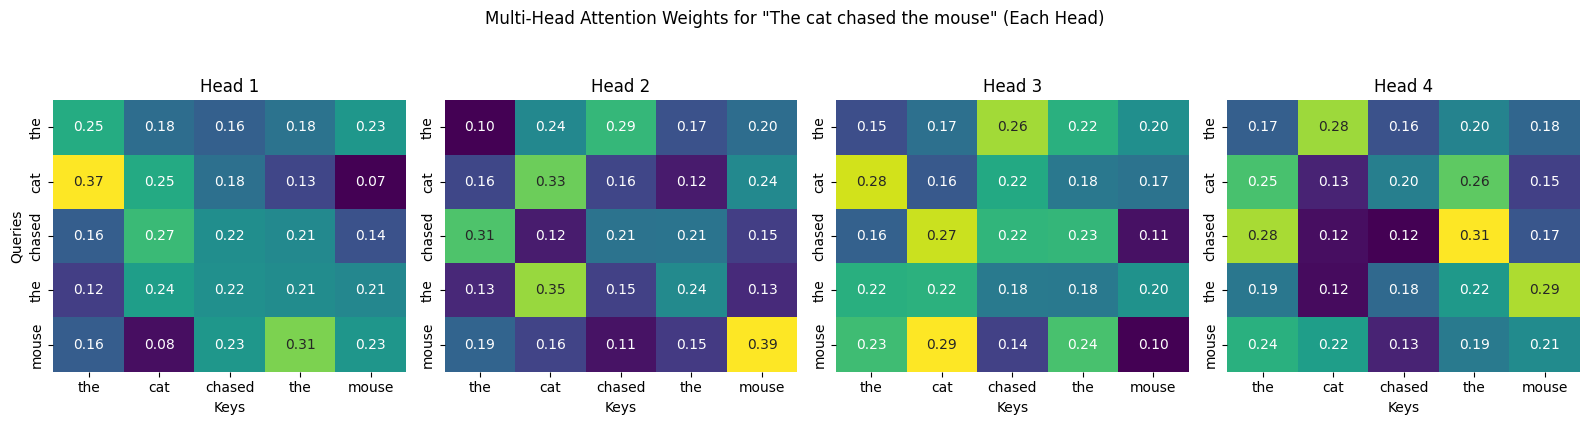

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the number of heads
num_heads = attention_weights_mha.shape[1]

plt.figure(figsize=(num_heads * 4, 4))

for i in range(num_heads):
    plt.subplot(1, num_heads, i + 1)
    sns.heatmap(
        attention_weights_mha[0, i, :, :].numpy(), # Batch 0, Head i, all queries, all keys
        xticklabels=token_list,
        yticklabels=token_list,
        cmap='viridis',
        annot=True,
        fmt=".2f",
        cbar=False
    )
    plt.title(f'Head {i+1}')
    plt.xlabel('Keys')
    plt.ylabel('Queries' if i == 0 else '')

plt.suptitle('Multi-Head Attention Weights for "The cat chased the mouse" (Each Head)', y=1.05)
plt.tight_layout()
plt.show()

### Task 6: Optimizer and Learning Rate Scheduling

Training a Transformer model often involves a custom learning rate schedule, rather than a fixed learning rate. This schedule typically involves a warm-up phase where the learning rate increases linearly, followed by a decay phase. This helps the model stabilize during early training and then fine-tune effectively.

Custom Learning Rate Schedule and Adam Optimizer defined.


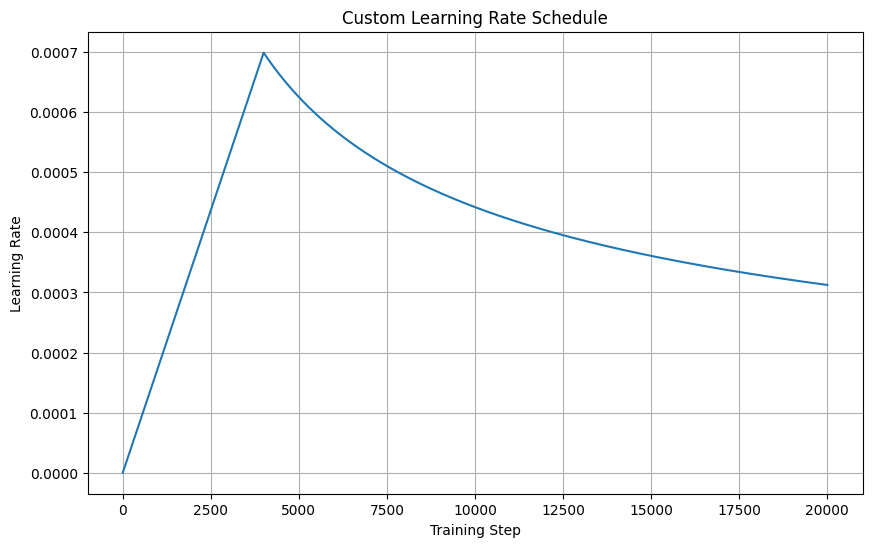

In [ ]:
class CustomSchedule(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, d_model, warmup_steps=4000):
        super(CustomSchedule, self).__init__()

        self.d_model = tf.cast(d_model, tf.float32)
        self.warmup_steps = tf.cast(warmup_steps, tf.float32)

    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        arg1 = tf.math.rsqrt(step)
        arg2 = step * (self.warmup_steps ** -1.5)

        return tf.math.rsqrt(self.d_model) * tf.math.minimum(arg1, arg2)


# Instantiate the custom learning rate schedule
# d_model is a critical hyperparameter that influences the learning rate scale
learning_rate = CustomSchedule(d_model) # Use the d_model from earlier (512)

# Define the Adam optimizer with custom learning rate
optimizer = tf.keras.optimizers.Adam(learning_rate,
                                     beta_1=0.9,
                                     beta_2=0.98,
                                     epsilon=1e-9)

print("Custom Learning Rate Schedule and Adam Optimizer defined.")

# Optional: Visualize the learning rate schedule
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
steps = tf.range(1, 20000, dtype=tf.float32)
lrs = [learning_rate(step) for step in steps]
plt.plot(steps.numpy(), lrs)
plt.xlabel('Training Step')
plt.ylabel('Learning Rate')
plt.title('Custom Learning Rate Schedule')
plt.grid(True)
plt.show()